In [ ]:
import os
os.listdir()

['.config', '.ipynb_checkpoints', 'data.csv', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df.shape

(4424, 37)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [ ]:
df.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [ ]:
X = df.drop('Target', axis=1)
y = df['Target']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
Dropout = 0
Graduate = 1
Enrolled = 2

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_scaled)

accuracy_score(y_test, y_pred)

0.752542372881356

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [ ]:
from sklearn.metrics import classification_report

rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.84      0.76      0.80       316
           1       0.48      0.30      0.37       151
           2       0.77      0.93      0.84       418

    accuracy                           0.76       885
   macro avg       0.70      0.66      0.67       885
weighted avg       0.74      0.76      0.75       885



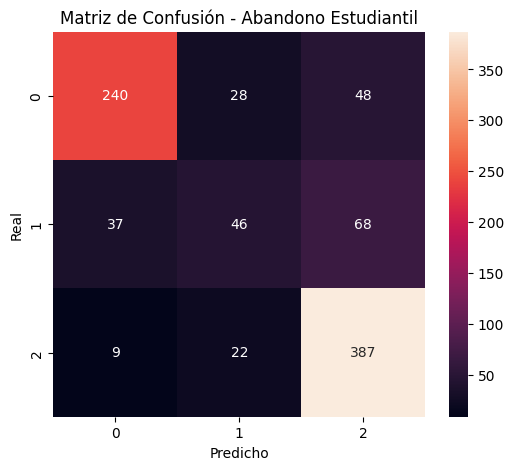

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Matriz de Confusión - Abandono Estudiantil")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

In [ ]:
import pandas as pd

importance = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

importance.head(10)

,Variable,Importancia
30,Curricular units 2nd sem (approved),0.145005
31,Curricular units 2nd sem (grade),0.100993
24,Curricular units 1st sem (approved),0.099389
25,Curricular units 1st sem (grade),0.062759
16,Tuition fees up to date,0.043371
29,Curricular units 2nd sem (evaluations),0.042782
12,Admission grade,0.042178
6,Previous qualification (grade),0.037270
19,Age at enrollment,0.035575
23,Curricular units 1st sem (evaluations),0.035234


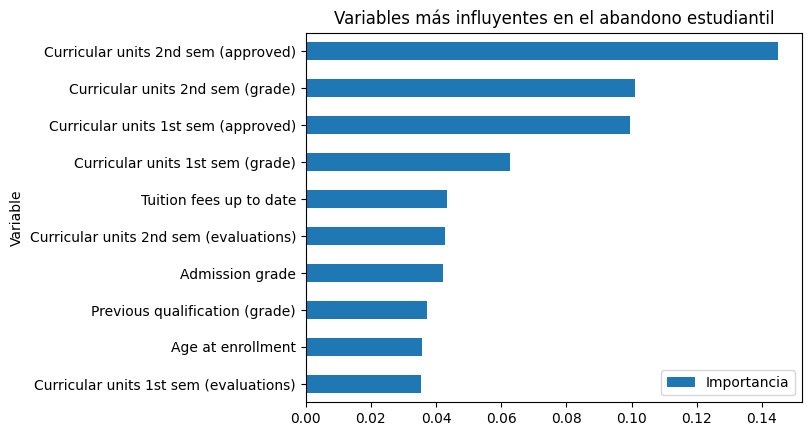

In [ ]:
importance.head(10).plot(
    x='Variable',
    y='Importancia',
    kind='barh'
)

plt.title("Variables más influyentes en el abandono estudiantil")
plt.gca().invert_yaxis()
plt.show()

# Predicción del Abandono Estudiantil mediante Modelos de Machine Learning

Autor: Yimari Acosta  
Programa: Ingeniería de Sistemas  
País: Colombia  
Año: 2026  
Área: Ciencia de Datos

El abandono estudiantil representa uno de los principales desafíos para las instituciones de educación superior a nivel mundial. La deserción académica genera impactos sociales, económicos e institucionales, afectando tanto a los estudiantes como a las universidades.

La Ciencia de Datos y el Machine Learning nos permite analizar grandes volúmenes de información académica para identificar patrones ocultos que ayudan a predecir comportamientos estudiantiles.

Este proyecto se plantea como una propuesta en el desarrollo de modelos predictivos capaces de identificar estudiantes con riesgo de abandono académico, apoyando la toma de decisiones basada en datos.

## Objetivo General

Desarrollar un modelo predictivo basado en técnicas de Machine Learning que permita clasificar a los estudiantes según su estado académico:

- Abandono
- Matriculado
- Graduado

con el fin de anticipar riesgos académicos y contribuir a estrategias de permanencia estudiantil.

El conjunto de datos que se utilizo contiene información académica, socioeconómica y administrativa de estudiantes universitarios.

Características principales:

- Total de registros: 4424 estudiantes
- Variables académicas y personales
- Variable objetivo: Estado académico del estudiante (Target)

El dataset permite analizar factores asociados al abandono estudiantil mediante técnicas de análisis predictivo.

El desarrollo del proyecto siguió las siguientes etapas:

1. Carga y exploración del dataset
2. Limpieza y preparación de datos
3. Codificación de variables categóricas
4. División en datos de entrenamiento y prueba
5. Escalamiento de variables
6. Entrenamiento de modelos de Machine Learning
7. Evaluación del rendimiento de los modelos
8. Análisis de importancia de variables

Se implementaron modelos de clasificación supervisada:

- Regresión Logística
- Random Forest

Estos algoritmos permiten identificar patrones complejos asociados al abandono académico.

El modelo Random Forest obtuvo una precisión aproximada del 75%, demostrando una capacidad adecuada para clasificar el estado académico de los estudiantes.

El análisis evidenció que variables relacionadas con el rendimiento académico, número de asignaturas aprobadas y desempeño académico general presentan mayor influencia en la predicción del abandono estudiantil.

CONCLUSIÓN

- El Machine Learning permite predecir el abandono estudiantil con un nivel adecuado de precisión.
- Los datos académicos representan el principal factor predictor del desempeño estudiantil.
- La analítica de datos puede apoyar la toma de decisiones estratégicas en educación superior.

Como trabajo futuro se propone:

- Implementar modelos de Deep Learning.
- Integrar dashboards interactivos para monitoreo institucional.
- Aplicar el modelo en entornos educativos reales.
- Desarrollar sistemas de alerta temprana para universidades.